# Lecture 2: Business and Housing Investment

**Macroeconomics B — Chapter 15B & 15C**

This notebook covers:
1. The investment function with quadratic adjustment costs
2. Comparative statics of the $q$-theory
3. Housing Tobin's $q$ and construction dynamics
4. Real-world example: tracing a monetary policy shock through the model

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['font.size'] = 12

## 1. The investment function: $q_t = 1 + c'(I_t)$

From the lecture, the firm maximises its value subject to adjustment costs. The first-order condition is:

$$q_t = 1 + c'(I_t)$$

With quadratic adjustment costs $c(I) = \frac{a}{2} I^2$, we get $c'(I) = aI$, so:

$$I_t = \frac{q_t - 1}{a}$$

Investment is a linear function of $q$ when adjustment costs are quadratic.

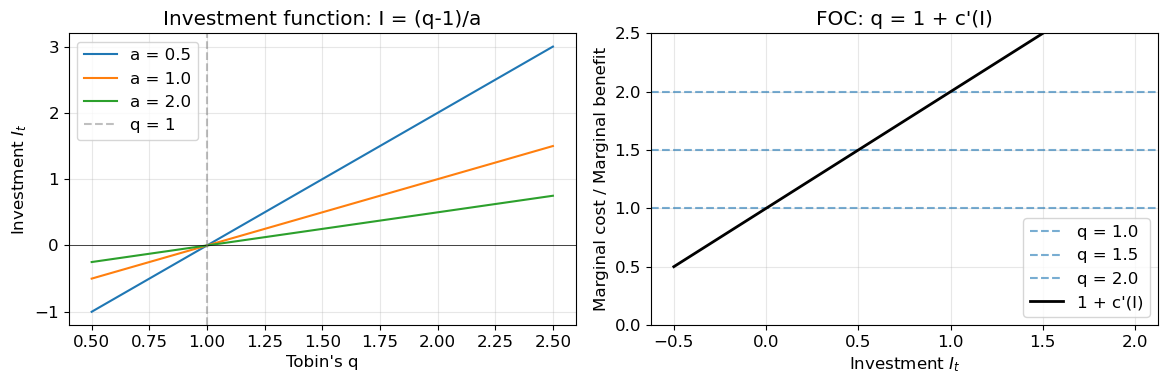

In [3]:
def investment(q, a):
    """Investment function: I = (q - 1) / a"""
    return (q - 1) / a

q_range = np.linspace(0.5, 2.5, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# (a) Investment as a function of q
for a in [0.5, 1.0, 2.0]:
    I = investment(q_range, a)
    ax1.plot(q_range, I, label=f'a = {a}')

ax1.axhline(0, color='black', lw=0.5)
ax1.axvline(1, color='gray', ls='--', alpha=0.5, label='q = 1')
ax1.set_xlabel("Tobin's q")
ax1.set_ylabel('Investment $I_t$')
ax1.set_title('Investment function: I = (q-1)/a')
ax1.legend()
ax1.grid(alpha=0.3)

# (b) FOC: the marginal cost = marginal benefit diagram
I_range = np.linspace(-0.5, 2, 200)
a = 1.0
marginal_cost = 1 + a * I_range  # 1 + c'(I)

for q_val in [1.0, 1.5, 2.0]:
    ax2.axhline(q_val, ls='--', alpha=0.6, label=f'q = {q_val}')

ax2.plot(I_range, marginal_cost, 'k-', lw=2, label='1 + c\'(I)')
ax2.set_xlabel('Investment $I_t$')
ax2.set_ylabel('Marginal cost / Marginal benefit')
ax2.set_title('FOC: q = 1 + c\'(I)')
ax2.set_ylim(0, 2.5)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Insight from the lecture:** Higher adjustment costs (larger $a$) make investment less responsive to $q$. This is why investment doesn't jump to infinity when $q > 1$.

## 2. Capital accumulation dynamics

From the lecture: $K_{t+1} = (1 - \delta)K_t + I_t$

Let's simulate what happens when $q$ jumps up (e.g., due to an increase in expected profits).

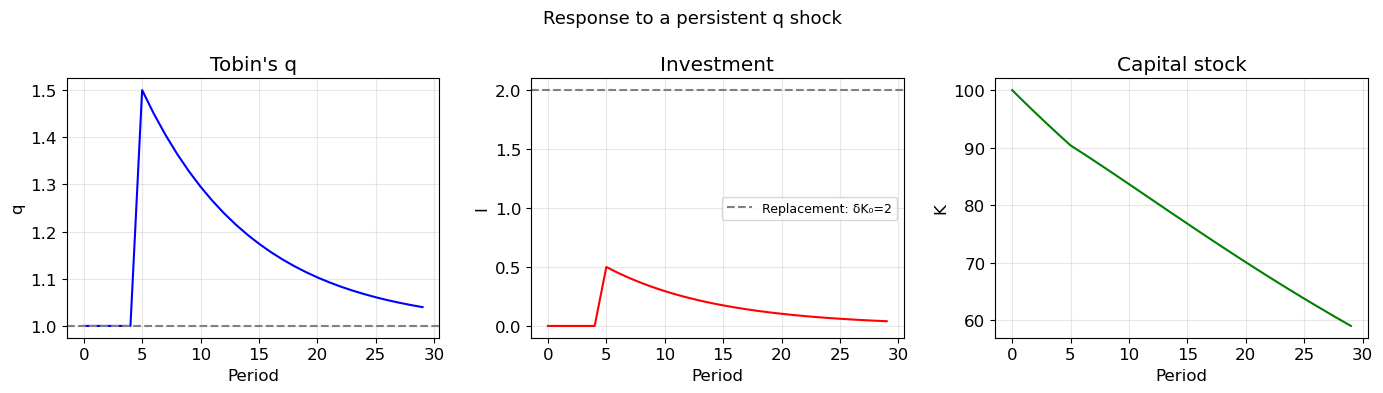

In [4]:
# Parameters
T = 30           # periods
K0 = 100         # initial capital
delta = 0.02     # depreciation rate
a = 1.0          # adjustment cost parameter

# q path: jumps from 1.0 to 1.5 at t=5, then slowly returns to 1.0
q_path = np.ones(T)
for t in range(5, T):
    q_path[t] = 1.0 + 0.5 * 0.9**(t - 5)  # gradual mean reversion

# Simulate
K = np.zeros(T)
I = np.zeros(T)
K[0] = K0

for t in range(T):
    I[t] = investment(q_path[t], a)
    if t < T - 1:
        K[t+1] = (1 - delta) * K[t] + I[t]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(range(T), q_path, 'b-')
axes[0].axhline(1, color='gray', ls='--')
axes[0].set_title("Tobin's q")
axes[0].set_xlabel('Period')
axes[0].set_ylabel('q')
axes[0].grid(alpha=0.3)

axes[1].plot(range(T), I, 'r-')
axes[1].axhline(delta * K0, color='gray', ls='--', label=f'Replacement: δK₀={delta*K0:.0f}')
axes[1].set_title('Investment')
axes[1].set_xlabel('Period')
axes[1].set_ylabel('I')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(range(T), K, 'g-')
axes[2].set_title('Capital stock')
axes[2].set_xlabel('Period')
axes[2].set_ylabel('K')
axes[2].grid(alpha=0.3)

plt.suptitle('Response to a persistent q shock', fontsize=13)
plt.tight_layout()
plt.show()

- **\(q\) jumps immediately, so investment jumps immediately.** When Tobin’s \(q\) rises at \(t=5\), firms want more capital, so \(I_t\) increases on impact.

- **The capital stock does not jump because it is predetermined.** Capital evolves according to \(K_{t+1} = (1-\delta)K_t + I_t\), so the higher investment at \(t=5\) only affects the stock from \(t=6\) onward.

- **Capital still declines, but more slowly.** In this calibration, investment rises after the shock but remains below replacement investment, so depreciation still dominates and \(K_t\) keeps falling, just at a slower rate.

## 3. Shock tracing

Let's trace the sign of effects on $q$ and $I$ by computing these using the Gordon model from Lecture 1 combined with the investment function.

Recall: $q = V/K$ and $V = D^e/(r + \varepsilon - g)$

In [5]:
K = 100  # replacement cost
a = 1.0  # adjustment cost

# Baseline
D, r, eps, g = 10, 0.03, 0.04, 0.02
V_base = D / (r + eps - g)
q_base = V_base / K
I_base = investment(q_base, a)

shocks = [
    ('Baseline', D, r, eps, g),
    ('1. Higher expected profits (D↑)', 12, r, eps, g),
    ('2. Higher real interest rate (r↑)', D, 0.05, eps, g),
    ('3. Higher risk premium (ε↑)', D, r, 0.07, g),
]

print(f'{"Scenario":<42} {"V":>7} {"q":>7} {"I":>7} {"ΔI":>7}')
print('-' * 72)
for name, D_s, r_s, eps_s, g_s in shocks:
    V = D_s / (r_s + eps_s - g_s)
    q = V / K
    I = investment(q, a)
    print(f'{name:<42} {V:>7.1f} {q:>7.2f} {I:>7.2f} {I - I_base:>+7.2f}')

Scenario                                         V       q       I      ΔI
------------------------------------------------------------------------
Baseline                                     200.0    2.00    1.00   +0.00
1. Higher expected profits (D↑)              240.0    2.40    1.40   +0.40
2. Higher real interest rate (r↑)            142.9    1.43    0.43   -0.57
3. Higher risk premium (ε↑)                  125.0    1.25    0.25   -0.75


## 4. Housing Tobin's q

From the lecture:

$$q_t^H = \frac{p_t^H}{P_t}$$

Housing investment responds to housing q:

$$I_t^H = \bar{I}^H + \phi(q_t^H - 1), \quad \phi > 0$$

Let's simulate a housing boom-bust cycle.

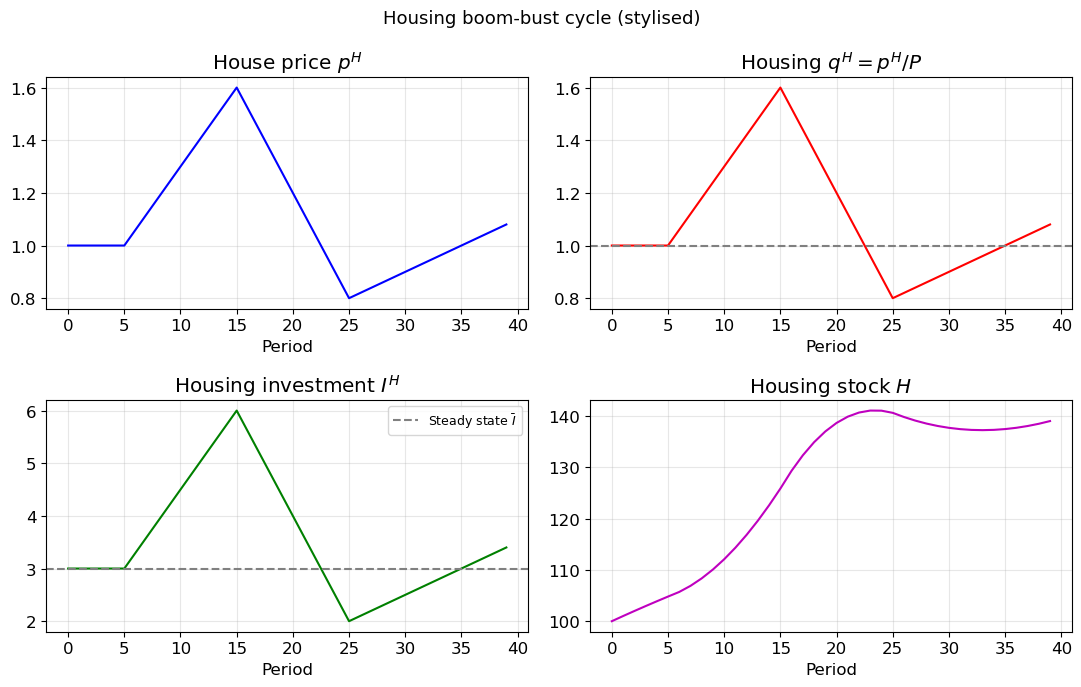

In [6]:
T = 40
delta_h = 0.02      # housing depreciation
phi = 5.0           # sensitivity of construction to q
I_bar = 3.0         # steady-state construction
H0 = 100            # initial housing stock

# Construction cost index (normalised to 1)
P_cost = np.ones(T)

# House price: boom (t=5-15), then bust (t=16-25), then recovery
p_house = np.ones(T)
for t in range(T):
    if t < 5:
        p_house[t] = 1.0
    elif t < 15:
        p_house[t] = 1.0 + 0.06 * (t - 5)  # boom
    elif t < 25:
        p_house[t] = 1.6 - 0.08 * (t - 15)  # bust
    else:
        p_house[t] = 0.8 + 0.02 * (t - 25)  # recovery

# Housing q and investment
q_h = p_house / P_cost
I_h = I_bar + phi * (q_h - 1)
I_h = np.maximum(I_h, 0)  # construction can't be negative

# Housing stock
H = np.zeros(T)
H[0] = H0
for t in range(T - 1):
    H[t+1] = (1 - delta_h) * H[t] + I_h[t]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0,0].plot(range(T), p_house, 'b-')
axes[0,0].set_title('House price $p^H$')
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(range(T), q_h, 'r-')
axes[0,1].axhline(1, color='gray', ls='--')
axes[0,1].set_title('Housing $q^H = p^H / P$')
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(range(T), I_h, 'g-')
axes[1,0].axhline(I_bar, color='gray', ls='--', label=f'Steady state $\\bar I$')
axes[1,0].set_title('Housing investment $I^H$')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(range(T), H, 'm-')
axes[1,1].set_title('Housing stock $H$')
axes[1,1].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Period')

plt.suptitle('Housing boom-bust cycle (stylised)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Denmark Housing q from FRED

We use:

- `QDKN628BIS`: Denmark residential property price index
- `OPCNRE01DKQ661N`: residential construction cost index
- `DNKPERMITQISMEI`: building permits for dwellings as a housing-activity proxy

We rebase price and cost to `2015 = 100` and then compute a **normalized housing q**:

$$q_t^H = \frac{p_t^H}{P_t}$$

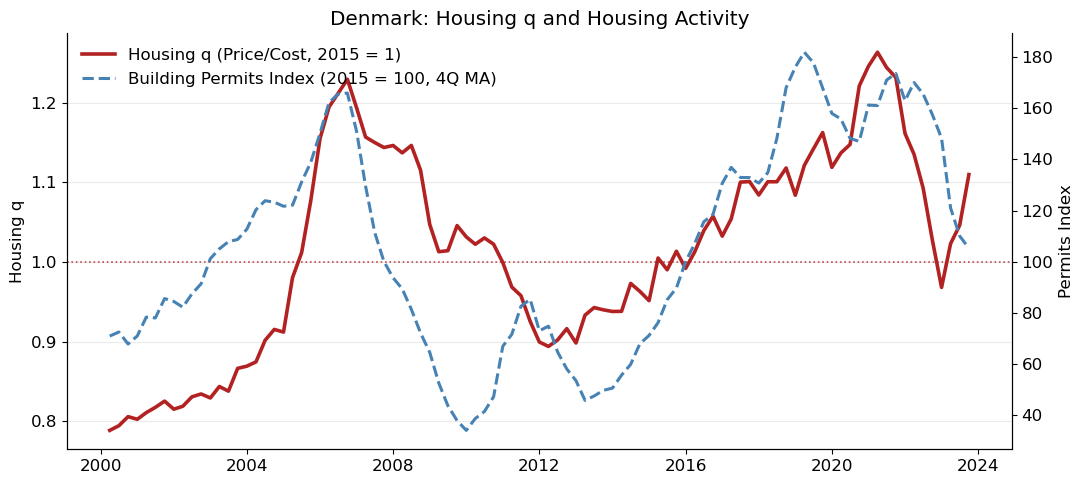

Data source: live FRED
Price series: QDKN628BIS
Construction cost series: OPCNRE01DKQ661N
Housing activity proxy: DNKPERMITQISMEI
Shared quarterly sample for the q plot: 2000Q1 to 2023Q3
The older WSCNDW01DKQ489N work-started series stops in 2018 on FRED, so the permits series avoids that cutoff.


In [7]:
from denmark_housing_q_data import SERIES_IDS, load_or_fetch_denmark_housing_q

housing_df, data_source = load_or_fetch_denmark_housing_q()
plot_df = housing_df.loc['2000Q1':].copy()
plot_dates = plot_df.index.to_timestamp(how='end')

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    plot_dates,
    plot_df['housing_q'],
    color='firebrick',
    linewidth=2.6,
    label='Housing q (Price/Cost, 2015 = 1)',
)
ax1.axhline(1.0, color='firebrick', linestyle=':', linewidth=1.2, alpha=0.8)
ax1.set_ylabel('Housing q')
ax1.set_title('Denmark: Housing q and Housing Activity')
ax1.grid(axis='y', alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(
    plot_dates,
    plot_df['permits_4q_ma'],
    color='steelblue',
    linewidth=2.2,
    linestyle='--',
    label='Building Permits Index (2015 = 100, 4Q MA)',
)
ax2.set_ylabel('Permits Index')

lines = ax1.get_lines() + ax2.get_lines()
lines = [line for line in lines if not line.get_label().startswith('_')]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left', frameon=False)

for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Data source: {data_source}')
print(f'Price series: {SERIES_IDS["price_index"]}')
print(f'Construction cost series: {SERIES_IDS["cost_index"]}')
print(f'Housing activity proxy: {SERIES_IDS["permits_index"]}')
print(
    'Shared quarterly sample for the q plot: '
    f'{plot_df.index.min()} to {plot_df.index.max()}'
)
print('The older WSCNDW01DKQ489N work-started series stops in 2018 on FRED, so the permits series avoids that cutoff.')

- Danish housing q shows two clear boom-bust cycles: a strong rise in the mid-2000s, a collapse after 2007, and another rise before the 2022-23 correction.

- Building permits move broadly with housing q, but more smoothly and with a lag, consistent with q driving construction.

- The 2022-23 fall fits the model well: higher interest rates lowered house prices, pushed q down, and were followed by a sharp drop in housing activity.


## 6. Average vs. marginal q

From the lecture: measured $q = V/K$ is *average* q, but the FOC uses *marginal* q.  
They coincide only with constant returns to scale. Otherwise, average q is an imperfect proxy.

Let's illustrate with a concave value function:

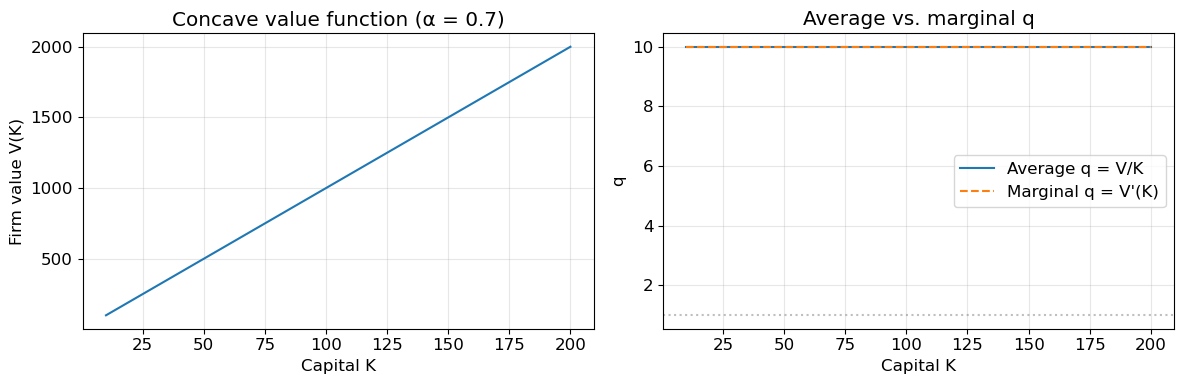

With decreasing returns, average q > marginal q.
Using average q overstates the investment incentive.


In [ ]:
# Concave value function: V = A * K^alpha
A = 10
alpha = 0.7  # decreasing returns to scale => concave V(K)
# alpha = 1.0  # linear V(K) 

K_range = np.linspace(10, 200, 200)
V_func = A * K_range**alpha
q_avg = V_func / K_range                  # average q
q_marg = A * alpha * K_range**(alpha - 1)  # marginal q = dV/dK

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, V_func)
ax1.set_xlabel('Capital K')
ax1.set_ylabel('Firm value V(K)')
ax1.set_title('Concave value function (α = 0.7)')
ax1.grid(alpha=0.3)

ax2.plot(K_range, q_avg, label='Average q = V/K')
ax2.plot(K_range, q_marg, label="Marginal q = V'(K)", ls='--')
ax2.axhline(1, color='gray', ls=':', alpha=0.5)
ax2.set_xlabel('Capital K')
ax2.set_ylabel('q')
ax2.set_title('Average vs. marginal q')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('With decreasing returns, average q > marginal q.')
print('Using average q overstates the investment incentive.')

## Summary

| Equation | Meaning |
|---|---|
| $K_{t+1} = (1-\delta)K_t + I_t$ | Capital accumulation |
| $q_t = 1 + c'(I_t)$ | Optimal investment rule |
| $I_t = (q_t - 1)/a$ | Investment function (quadratic costs) |
| $q_t^H = p_t^H / P_t$ | Housing Tobin's q |
| $I_t^H = \bar{I}^H + \phi(q_t^H - 1)$ | Housing investment function |